# VAMPS — Fiji Example using the C Extension

This notebook runs the **fiji pine forest** simulation using the `vampspy._vampscore`
C extension — no subprocess, no temp files.  Everything runs in-process.

**Setup** (run once from the repo root):
```bash
pip install -e .
```

The fiji example has:
- **61 daily timesteps**
- **77 soil layers** (Van Genuchten hydraulics)
- **Penman-Monteith canopy** (top system 5)
- **Gash interception model**

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Make vampspy importable without a full install
REPO = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, REPO)

from vampspy import _vampscore
print('vampspy._vampscore loaded:', _vampscore.__file__)

vampspy._vampscore loaded: /Users/jaap/Nextcloud/src/vamps/vampspy/_vampscore.cpython-313-darwin.so


## 1. Load forcing data

The fiji forcing files are two-column ASCII `(timestep, value)`.  
We use `numpy.loadtxt` to grab the value column.

In [2]:
DATA_DIR = os.path.join(REPO, 'examples', 'fiji')

def load_prn(fname, col=1):
    """Load a VAMPS .prn forcing file; return the value column."""
    return np.loadtxt(os.path.join(DATA_DIR, fname), usecols=col)

forcing = {
    'pre': load_prn('precip.prn'),   # precipitation      [cm/day]
    'nra': load_prn('rnet.prn'),     # net radiation      [W/m²]
    'ira': load_prn('inrad.prn'),    # incoming radiation [W/m²]
    'rlh': load_prn('rh.prn'),       # relative humidity  [fraction]
    'tem': load_prn('newt.prn'),     # air temperature    [°C]
    'win': load_prn('wind.prn'),     # wind speed         [m/s]
}

days = np.arange(1, len(forcing['pre']) + 1)
print(f"Loaded {len(days)} days of forcing data")
for k, v in forcing.items():
    print(f"  {k}: min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}")

Loaded 92 days of forcing data
  pre: min=0.000  max=6.532  mean=0.401
  nra: min=14.096  max=215.808  mean=126.972
  ira: min=27.286  max=287.728  mean=177.005
  rlh: min=67.109  max=97.691  mean=83.829
  tem: min=18.862  max=24.735  mean=21.596
  win: min=0.941  max=4.108  mean=1.880


In [3]:
print(forcing)

{'pre': array([0.        , 0.        , 0.        , 0.        , 0.24120048,
       0.        , 0.        , 0.02010016, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 1.18589743,
       2.63309694, 0.30150048, 0.44219775, 0.04020032, 0.        ,
       0.        , 0.        , 0.        , 0.04019984, 0.68340209,
       0.06030048, 0.08040016, 0.        , 0.        , 0.24120048,
       0.04019984, 0.02009968, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.02010016,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.02010016, 0.02010016, 0.02010016, 0.        , 1.92960579,
       6.53249148, 0.32160113, 0.        , 0.        , 2.78335128,
       0.47235209, 0.72360434, 0.10049984, 0.46229598, 5.82881865,
       0.50249775, 0.72359711, 1.06529646, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.02010016, 0.        ,
       0.        , 0.        , 0.16079887, 3.31620916,

## 2. Run the model

`_vampscore.run(config_file, forcing_dict, firststep)` runs VAMPS in-process and
returns a dict of NumPy arrays.  The forcing dict overrides the file paths in
the `[ts]` section of the `.inp` file, so no data files need to be on disk.

In [4]:
import time

INP = os.path.join(DATA_DIR, 'fiji.inp')

# Run from the fiji directory so relative paths in fiji.inp resolve
os.chdir(DATA_DIR)

t0 = time.perf_counter()
result = _vampscore.run(INP, forcing, firststep=1.0)
elapsed = time.perf_counter() - t0

print(f"Completed in {elapsed*1000:.1f} ms")
print(f"Output keys: {list(result.keys())}")
print(f"Steps: {result['volact'].shape[0]}")
print(f"Soil layers: {result['theta'].shape[1]}")

Completed in 68.2 ms
Output keys: ['t', 'volact', 'SMD', 'qtop', 'qbot', 'avgtheta', 'cumprec', 'cumtra', 'cumeva', 'cumintc', 'masbal', 'precipitation', 'interception', 'transpiration', 'soilevaporation', 'theta', 'k', 'h', 'q', 'inq', 'qrot', 'howsat', 'gwl', '_steps', '_nlayers']
Steps: 61
Soil layers: 77






+-----------------------------------------------------------------------------+
| time              |  running | to_go |   [masbal, it,   err, dt,water_cont] |
+-----------------------------------------------------------------------------+
|        61.000000  |    0 sec.|    0  |   [-0.039,  1,    0,0.000400,79.245] |


## 3. Summary

In [5]:
r = result
print(f"Final water storage (volact) : {r['volact'][-1]:.3f} cm")
print(f"Final soil moisture deficit  : {r['SMD'][-1]:.3f} cm")
print(f"Cumulative precipitation     : {r['cumprec'][-1]:.2f} cm")
print(f"Cumulative transpiration     : {r['cumtra'][-1]:.2f} cm")
print(f"Cumulative soil evaporation  : {r['cumeva'][-1]:.2f} cm")
print(f"Cumulative interception      : {r['cumintc'][-1]:.2f} cm")
print(f"Final mass balance error     : {r['masbal'][-1]:.4f} cm")

Final water storage (volact) : 79.245 cm
Final soil moisture deficit  : 5.426 cm
Cumulative precipitation     : 25.77 cm
Cumulative transpiration     : 15.05 cm
Cumulative soil evaporation  : 0.37 cm
Cumulative interception      : 4.89 cm
Final mass balance error     : -0.0389 cm


## 4. Plots

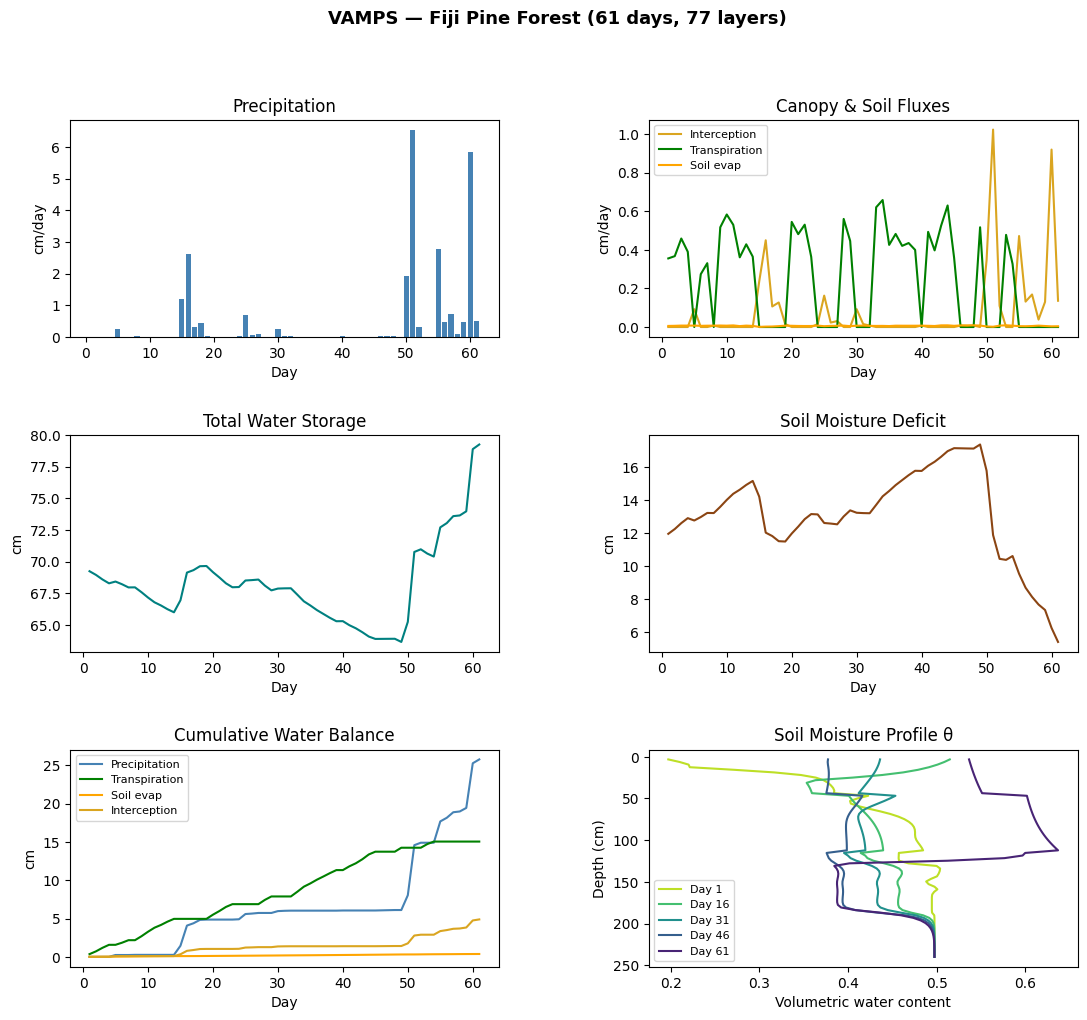

Saved fiji_vampscore_results.png


In [6]:
fig = plt.figure(figsize=(13, 11))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

step_days = days[:r['volact'].shape[0]]   # x-axis for output

# --- Precipitation ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(step_days, r['precipitation'], color='steelblue', width=0.8)
ax1.set_title('Precipitation')
ax1.set_ylabel('cm/day')
ax1.set_xlabel('Day')

# --- Water balance fluxes ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(step_days, r['interception'],    label='Interception', color='goldenrod')
ax2.plot(step_days, r['transpiration'],   label='Transpiration', color='green')
ax2.plot(step_days, r['soilevaporation'], label='Soil evap', color='orange')
ax2.set_title('Canopy & Soil Fluxes')
ax2.set_ylabel('cm/day')
ax2.set_xlabel('Day')
ax2.legend(fontsize=8)

# --- Total water storage ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(step_days, r['volact'], color='teal', linewidth=1.5)
ax3.set_title('Total Water Storage')
ax3.set_ylabel('cm')
ax3.set_xlabel('Day')

# --- Soil moisture deficit ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(step_days, r['SMD'], color='saddlebrown', linewidth=1.5)
ax4.set_title('Soil Moisture Deficit')
ax4.set_ylabel('cm')
ax4.set_xlabel('Day')

# --- Cumulative water balance ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(step_days, r['cumprec'],  label='Precipitation', color='steelblue')
ax5.plot(step_days, r['cumtra'],   label='Transpiration', color='green')
ax5.plot(step_days, r['cumeva'],   label='Soil evap',     color='orange')
ax5.plot(step_days, r['cumintc'],  label='Interception',  color='goldenrod')
ax5.set_title('Cumulative Water Balance')
ax5.set_ylabel('cm')
ax5.set_xlabel('Day')
ax5.legend(fontsize=8)

# --- Soil moisture profiles at selected days ---
ax6 = fig.add_subplot(gs[2, 1])
theta = r['theta']            # shape (steps, layers)
n_layers = theta.shape[1]
depth_cm = np.arange(1, n_layers + 1) * (240.0 / n_layers)   # approximate depths
colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, 5))
for k, day in enumerate([1, 16, 31, 46, 61]):
    idx = min(day - 1, theta.shape[0] - 1)
    ax6.plot(theta[idx], depth_cm, label=f'Day {day}', color=colors[k])
ax6.invert_yaxis()
ax6.set_title('Soil Moisture Profile θ')
ax6.set_xlabel('Volumetric water content')
ax6.set_ylabel('Depth (cm)')
ax6.legend(fontsize=8)

fig.suptitle('VAMPS — Fiji Pine Forest (61 days, 77 layers)', fontsize=13, fontweight='bold')
plt.savefig('fiji_vampscore_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved fiji_vampscore_results.png')

## 6. Multiple runs — idempotency check

A key feature of the C extension is that it resets all global C state between
calls, so repeated `run()` calls give bit-for-bit identical results.

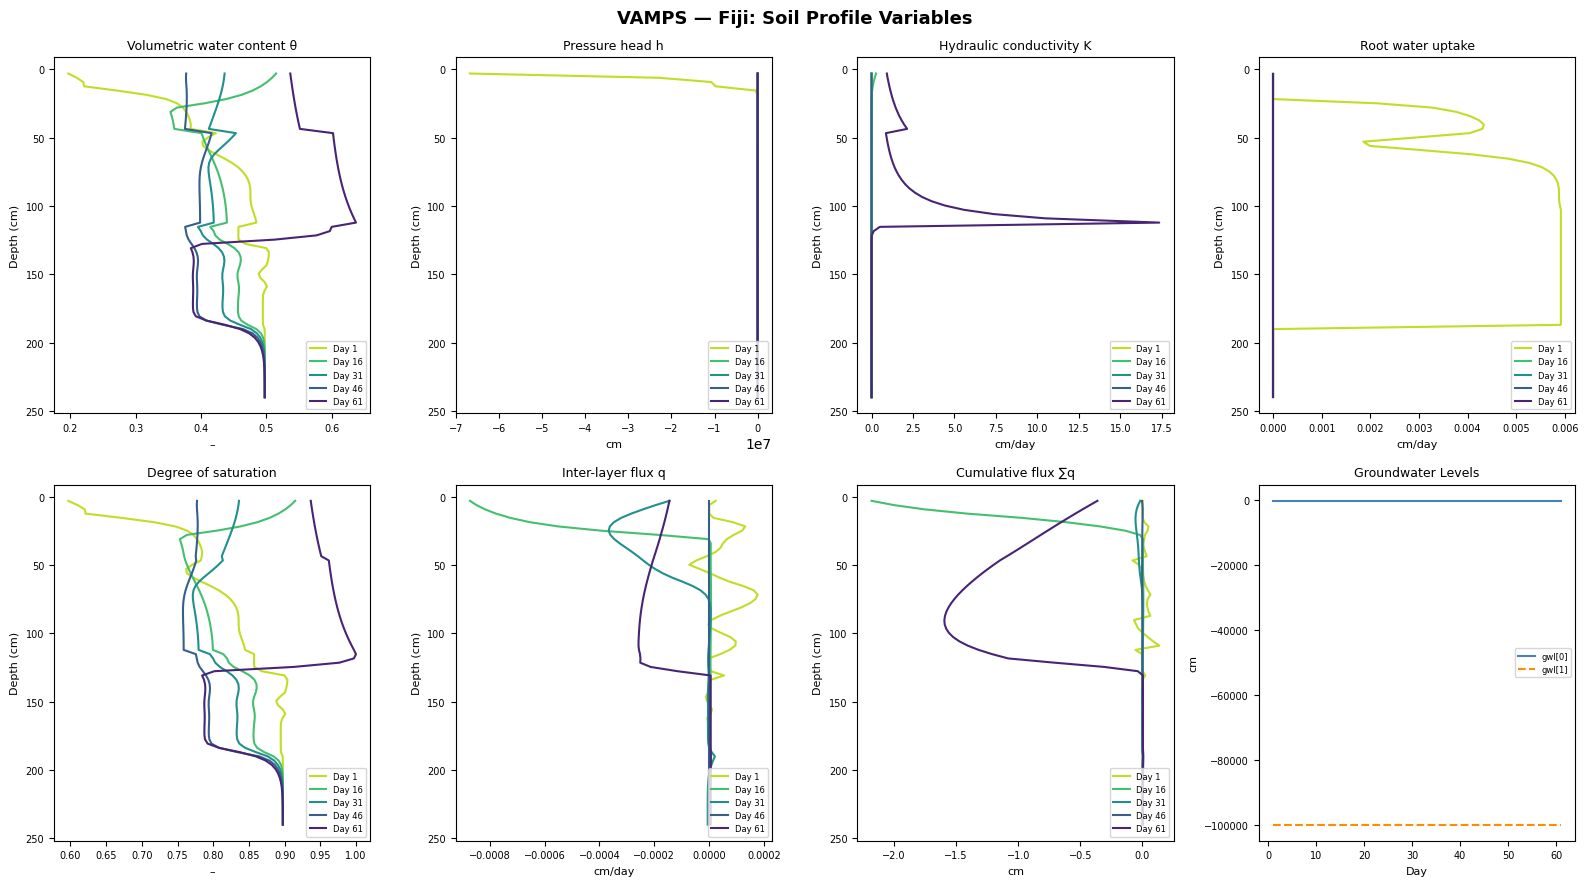

Saved fiji_vampscore_profiles.png


In [7]:
nl     = result['_nlayers']           # 77
steps  = result['_steps']             # 61
# Approximate layer mid-point depths (each layer is 240/77 ≈ 3.1 cm thick)
layer_depth = np.arange(1, nl + 1) * (240.0 / nl)

# Select a handful of timesteps to show profile evolution
sel_days  = [1, 16, 31, 46, 61]
sel_idx   = [d - 1 for d in sel_days]
colors    = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(sel_days)))

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('VAMPS — Fiji: Soil Profile Variables', fontsize=13, fontweight='bold')

profile_specs = [
    ('theta',  result['theta'],          nl,     'Volumetric water content θ',  '–'),
    ('h',      result['h'],              nl,     'Pressure head h',             'cm'),
    ('k',      result['k'],              nl,     'Hydraulic conductivity K',    'cm/day'),
    ('qrot',   result['qrot'],           nl,     'Root water uptake',           'cm/day'),
    ('howsat', result['howsat'],         nl,     'Degree of saturation',        '–'),
    ('q',      result['q'][:, :nl],     nl,     'Inter-layer flux q',          'cm/day'),
    ('inq',    result['inq'][:, :nl],   nl,     'Cumulative flux ∑q',          'cm'),
]

for ax, (key, arr, ncols, title, unit) in zip(axes.flat, profile_specs):
    for j, (idx, day) in enumerate(zip(sel_idx, sel_days)):
        ax.plot(arr[idx, :ncols], layer_depth, color=colors[j], label=f'Day {day}')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(unit, fontsize=8)
    ax.set_ylabel('Depth (cm)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, loc='lower right')

# GWL time series (2 values per step) in the last panel
ax_gwl = axes.flat[7]
ax_gwl.plot(np.arange(1, steps + 1), result['gwl'][:, 0], label='gwl[0]', color='steelblue')
ax_gwl.plot(np.arange(1, steps + 1), result['gwl'][:, 1], label='gwl[1]', color='darkorange', linestyle='--')
ax_gwl.set_title('Groundwater Levels', fontsize=9)
ax_gwl.set_xlabel('Day', fontsize=8)
ax_gwl.set_ylabel('cm', fontsize=8)
ax_gwl.tick_params(labelsize=7)
ax_gwl.legend(fontsize=6)

plt.tight_layout()
plt.savefig('fiji_vampscore_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved fiji_vampscore_profiles.png')

## 5. Multiple runs — idempotency check

A key feature of the C extension is that it resets all global C state between
calls, so repeated `run()` calls give bit-for-bit identical results.

In [8]:
runs = []
for i in range(3):
    t0 = time.perf_counter()
    res = _vampscore.run(INP, forcing, firststep=1.0)
    dt = time.perf_counter() - t0
    runs.append(res['volact'][-1])
    print(f"Run {i+1}: volact[-1]={res['volact'][-1]:.6f} cm  ({dt*1000:.0f} ms)")

assert all(v == runs[0] for v in runs), "Results differ between runs!"
print("\n✓ All runs produce identical results.")

Run 1: volact[-1]=79.244909 cm  (68 ms)
Run 2: volact[-1]=79.244909 cm  (67 ms)
Run 3: volact[-1]=79.244909 cm  (68 ms)

✓ All runs produce identical results.


|        61.000000  |    0 sec.|    0  |   [-0.039,  1,    0,0.000400,79.245] |
|        61.000000  |    0 sec.|    0  |   [-0.039,  1,    0,0.000400,79.245] |
|        61.000000  |    0 sec.|    0  |   [-0.039,  1,    0,0.000400,79.245] |
